In [1755]:
import re

In [1756]:
input = '''broadcaster -> a
%a -> inv, con
&inv -> b
%b -> con
&con -> output'''

In [1757]:
input = '''%rq -> ch, sj
%nf -> sm, rg
%pc -> rz, zp
%xt -> bc
%nt -> kq, sj
%hc -> kb, zp
%rd -> lk
%ml -> pp, xt
%sq -> kl, sj
%jg -> fl, rg
&xl -> df
%kl -> mb, sj
%nd -> rg, jg
&rg -> cs, zb, cp, vz, gp
%mf -> zp
%rz -> zp, fr
%kk -> rg, bj
%nb -> qj
%pr -> pp
&zp -> vl, lk, rd, kb, xl
%fl -> nf, rg
%tb -> pk, pp
%bh -> pp, pr
%nh -> sj, rq
%lk -> hc
%cp -> kk
&ln -> df
&xp -> df
%bc -> nb, pp
%lj -> rg
%vz -> nd
%vl -> lv, zp
&gp -> df
%hd -> pp, bq
%fq -> pp, bh
%pk -> fq, pp
%cs -> zb, rg
%sn -> fd
%kq -> sj, qq
%zb -> vz
%lv -> zp, rd
%qj -> pp, hd
%fd -> nt
&df -> rx
broadcaster -> vl, cs, cn, ml
%bq -> tb
%kb -> pc
%cn -> sn, sj
%qq -> sq
%mb -> sj, nh
%jd -> zp, mf
&sj -> xp, qq, cn, fd, sn
&pp -> ln, ml, xt, bq, nb
%sm -> rg, cp
%ch -> sj
%bj -> lj, rg
%fr -> zp, mr
%mr -> zp, jd'''

In [1758]:
print(input)

%rq -> ch, sj
%nf -> sm, rg
%pc -> rz, zp
%xt -> bc
%nt -> kq, sj
%hc -> kb, zp
%rd -> lk
%ml -> pp, xt
%sq -> kl, sj
%jg -> fl, rg
&xl -> df
%kl -> mb, sj
%nd -> rg, jg
&rg -> cs, zb, cp, vz, gp
%mf -> zp
%rz -> zp, fr
%kk -> rg, bj
%nb -> qj
%pr -> pp
&zp -> vl, lk, rd, kb, xl
%fl -> nf, rg
%tb -> pk, pp
%bh -> pp, pr
%nh -> sj, rq
%lk -> hc
%cp -> kk
&ln -> df
&xp -> df
%bc -> nb, pp
%lj -> rg
%vz -> nd
%vl -> lv, zp
&gp -> df
%hd -> pp, bq
%fq -> pp, bh
%pk -> fq, pp
%cs -> zb, rg
%sn -> fd
%kq -> sj, qq
%zb -> vz
%lv -> zp, rd
%qj -> pp, hd
%fd -> nt
&df -> rx
broadcaster -> vl, cs, cn, ml
%bq -> tb
%kb -> pc
%cn -> sn, sj
%qq -> sq
%mb -> sj, nh
%jd -> zp, mf
&sj -> xp, qq, cn, fd, sn
&pp -> ln, ml, xt, bq, nb
%sm -> rg, cp
%ch -> sj
%bj -> lj, rg
%fr -> zp, mr
%mr -> zp, jd


In [1759]:
input = input.split('\n')

In [1760]:
def flatten(lst):
    return [item for sublist in lst for item in (flatten(sublist) if isinstance(sublist, list) else [sublist])]

In [1761]:
input = [line.split(' ') for line in input]
input = [[re.findall(r'&|%|\w+',line[0])]+[str.replace(',','') for str in line[2:]] for line in input]
input = [flatten(line) for line in input]
print(input)

[['%', 'rq', 'ch', 'sj'], ['%', 'nf', 'sm', 'rg'], ['%', 'pc', 'rz', 'zp'], ['%', 'xt', 'bc'], ['%', 'nt', 'kq', 'sj'], ['%', 'hc', 'kb', 'zp'], ['%', 'rd', 'lk'], ['%', 'ml', 'pp', 'xt'], ['%', 'sq', 'kl', 'sj'], ['%', 'jg', 'fl', 'rg'], ['&', 'xl', 'df'], ['%', 'kl', 'mb', 'sj'], ['%', 'nd', 'rg', 'jg'], ['&', 'rg', 'cs', 'zb', 'cp', 'vz', 'gp'], ['%', 'mf', 'zp'], ['%', 'rz', 'zp', 'fr'], ['%', 'kk', 'rg', 'bj'], ['%', 'nb', 'qj'], ['%', 'pr', 'pp'], ['&', 'zp', 'vl', 'lk', 'rd', 'kb', 'xl'], ['%', 'fl', 'nf', 'rg'], ['%', 'tb', 'pk', 'pp'], ['%', 'bh', 'pp', 'pr'], ['%', 'nh', 'sj', 'rq'], ['%', 'lk', 'hc'], ['%', 'cp', 'kk'], ['&', 'ln', 'df'], ['&', 'xp', 'df'], ['%', 'bc', 'nb', 'pp'], ['%', 'lj', 'rg'], ['%', 'vz', 'nd'], ['%', 'vl', 'lv', 'zp'], ['&', 'gp', 'df'], ['%', 'hd', 'pp', 'bq'], ['%', 'fq', 'pp', 'bh'], ['%', 'pk', 'fq', 'pp'], ['%', 'cs', 'zb', 'rg'], ['%', 'sn', 'fd'], ['%', 'kq', 'sj', 'qq'], ['%', 'zb', 'vz'], ['%', 'lv', 'zp', 'rd'], ['%', 'qj', 'pp', 'hd'], ['%

In [1762]:
from collections import defaultdict

In [1763]:
state = {}
for module in input:
    if module[0] == 'broadcaster':
        state['broadcaster'] = ['b',[]] + [module[1:]]
    elif module[0] == '&': ### type, state, receivees
        state[module[1]] = [1, {}] + [module[2:]]
        
    else:
        state[module[1]] = [2, False] + [module[2:]]
state['rx'] = [4,[],[]]

In [1764]:
print(state)

{'rq': [2, False, ['ch', 'sj']], 'nf': [2, False, ['sm', 'rg']], 'pc': [2, False, ['rz', 'zp']], 'xt': [2, False, ['bc']], 'nt': [2, False, ['kq', 'sj']], 'hc': [2, False, ['kb', 'zp']], 'rd': [2, False, ['lk']], 'ml': [2, False, ['pp', 'xt']], 'sq': [2, False, ['kl', 'sj']], 'jg': [2, False, ['fl', 'rg']], 'xl': [1, {}, ['df']], 'kl': [2, False, ['mb', 'sj']], 'nd': [2, False, ['rg', 'jg']], 'rg': [1, {}, ['cs', 'zb', 'cp', 'vz', 'gp']], 'mf': [2, False, ['zp']], 'rz': [2, False, ['zp', 'fr']], 'kk': [2, False, ['rg', 'bj']], 'nb': [2, False, ['qj']], 'pr': [2, False, ['pp']], 'zp': [1, {}, ['vl', 'lk', 'rd', 'kb', 'xl']], 'fl': [2, False, ['nf', 'rg']], 'tb': [2, False, ['pk', 'pp']], 'bh': [2, False, ['pp', 'pr']], 'nh': [2, False, ['sj', 'rq']], 'lk': [2, False, ['hc']], 'cp': [2, False, ['kk']], 'ln': [1, {}, ['df']], 'xp': [1, {}, ['df']], 'bc': [2, False, ['nb', 'pp']], 'lj': [2, False, ['rg']], 'vz': [2, False, ['nd']], 'vl': [2, False, ['lv', 'zp']], 'gp': [1, {}, ['df']], 'hd

In [1765]:
### init conjucionts
cons = []
for module,s in state.items():
    if s[0] == '&':
        cons.append(module)
print(cons)
for module,s in state.items():
    if module == 'a':
        print(s[2])
    for dest in s[2]:
        if dest in cons:
            state[dest][1][module] = False
print(state)



[]
{'rq': [2, False, ['ch', 'sj']], 'nf': [2, False, ['sm', 'rg']], 'pc': [2, False, ['rz', 'zp']], 'xt': [2, False, ['bc']], 'nt': [2, False, ['kq', 'sj']], 'hc': [2, False, ['kb', 'zp']], 'rd': [2, False, ['lk']], 'ml': [2, False, ['pp', 'xt']], 'sq': [2, False, ['kl', 'sj']], 'jg': [2, False, ['fl', 'rg']], 'xl': [1, {}, ['df']], 'kl': [2, False, ['mb', 'sj']], 'nd': [2, False, ['rg', 'jg']], 'rg': [1, {}, ['cs', 'zb', 'cp', 'vz', 'gp']], 'mf': [2, False, ['zp']], 'rz': [2, False, ['zp', 'fr']], 'kk': [2, False, ['rg', 'bj']], 'nb': [2, False, ['qj']], 'pr': [2, False, ['pp']], 'zp': [1, {}, ['vl', 'lk', 'rd', 'kb', 'xl']], 'fl': [2, False, ['nf', 'rg']], 'tb': [2, False, ['pk', 'pp']], 'bh': [2, False, ['pp', 'pr']], 'nh': [2, False, ['sj', 'rq']], 'lk': [2, False, ['hc']], 'cp': [2, False, ['kk']], 'ln': [1, {}, ['df']], 'xp': [1, {}, ['df']], 'bc': [2, False, ['nb', 'pp']], 'lj': [2, False, ['rg']], 'vz': [2, False, ['nd']], 'vl': [2, False, ['lv', 'zp']], 'gp': [1, {}, ['df']], 

In [1766]:
#### False = low signal when conjucntion and False = Off when Flip FLop

In [1767]:
def check(d):
    test = True
    for (k,v) in d.items():
        if v == False:
            test = False
            break
    return test

In [1768]:
### returns list of pulses to destinations
def send_pulse(pulsepair,origin):
    pulse = pulsepair[1]
    o = pulsepair[0]
    if origin == 'rx':
        state['rx'][1].append(pulsepair)
        return ['end']
    if state[origin][0] == '%':
        if not pulse:
            if state[origin][1]:
                state[origin][1] = False
                return [[dest,False,origin] for dest in state[origin][2]]
            else:
                state[origin][1] = True
                return [[dest,True,origin] for dest in state[origin][2]]
    if state[origin][0] == '&':
        state[origin][1][o] = pulse
        if check(state[origin][1]):
            return [[dest,False,origin] for dest in state[origin][2]]
        else:
            return [[dest,True,origin] for dest in state[origin][2]]
    return ['end']
    

In [1769]:
def checkRX(rx):
    for pulse in rx[1]:
        if pulse[1] == False:
            return True
    return False

In [1770]:
state2 = state.copy()

In [1771]:
def thing():
    for k in range(1,1000000):#1656000000):
        q = []
        state['rx'] = state['rx'] = ['rxt',[],[]]
        # init queue
        for dest in state['broadcaster'][2]:
            # broadcaster sends all modules in its outputs a low pulse since the button sends a low pulse to the broadcaster
            q.append([dest,False,'broadcaster'])
        while(q):
            pulse_triple = q.pop(0)
            if pulse_triple == 'end':
                continue
            pulse_pair = [pulse_triple[2],pulse_triple[1]]
            origin = pulse_triple[0]
            if check(state['rg'][1]):
                print(k)
            q+=send_pulse(pulse_pair,origin)

    

In [1772]:
import math

In [1773]:
print(math.lcm(3833,4051,4021,4057))

253302889093151


In [1774]:
(2**(12*4) )

281474976710656

In [1775]:
import networkx as nx
G = nx.Graph()
for (k,v) in state.items():
    if k!= 'rx' and k!= 'broadcaster':
            for dest in v[2]:
                G.add_edge((k,v[0]),(dest,state[dest][0]),weight = 0)


In [1776]:
print(state['df'])

[1, {}, ['rx']]


In [1777]:
 from matplotlib.colors import LinearSegmentedColormap

# Dracula Theme Colors
dracula_colors = list(reversed(["#282a36", "#44475a", "#6272a4", "#ffb86c", "#ff79c6", "#bd93f9", "#ff5555"]))
n_bins = [4] * len(dracula_colors)  # Number of bins for each color
# Create a colormap
cm = LinearSegmentedColormap.from_list("Dracula", dracula_colors, N=sum(n_bins))
import matplotlib.pyplot as plt
node_colors = [(G.degree(node)*(state[node[0]][0])*0.2) for node in G.nodes()]
print(node_colors)

[1.2000000000000002, 0.8, 2.6, 1.2000000000000002, 1.2000000000000002, 2.6, 1.2000000000000002, 1.2000000000000002, 2.6, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 0.8, 2.6, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 0.4, 1.0, 1.2000000000000002, 1.2000000000000002, 0.8, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 0.4, 0.8, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 0.8, 0.8, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 0.4, 0.4, 0.8, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 1.2000000000000002, 0.8, 0.8, 1.2000000000000002, 1.2000000000000002]


In [1778]:
import matplotlib.pyplot as plt

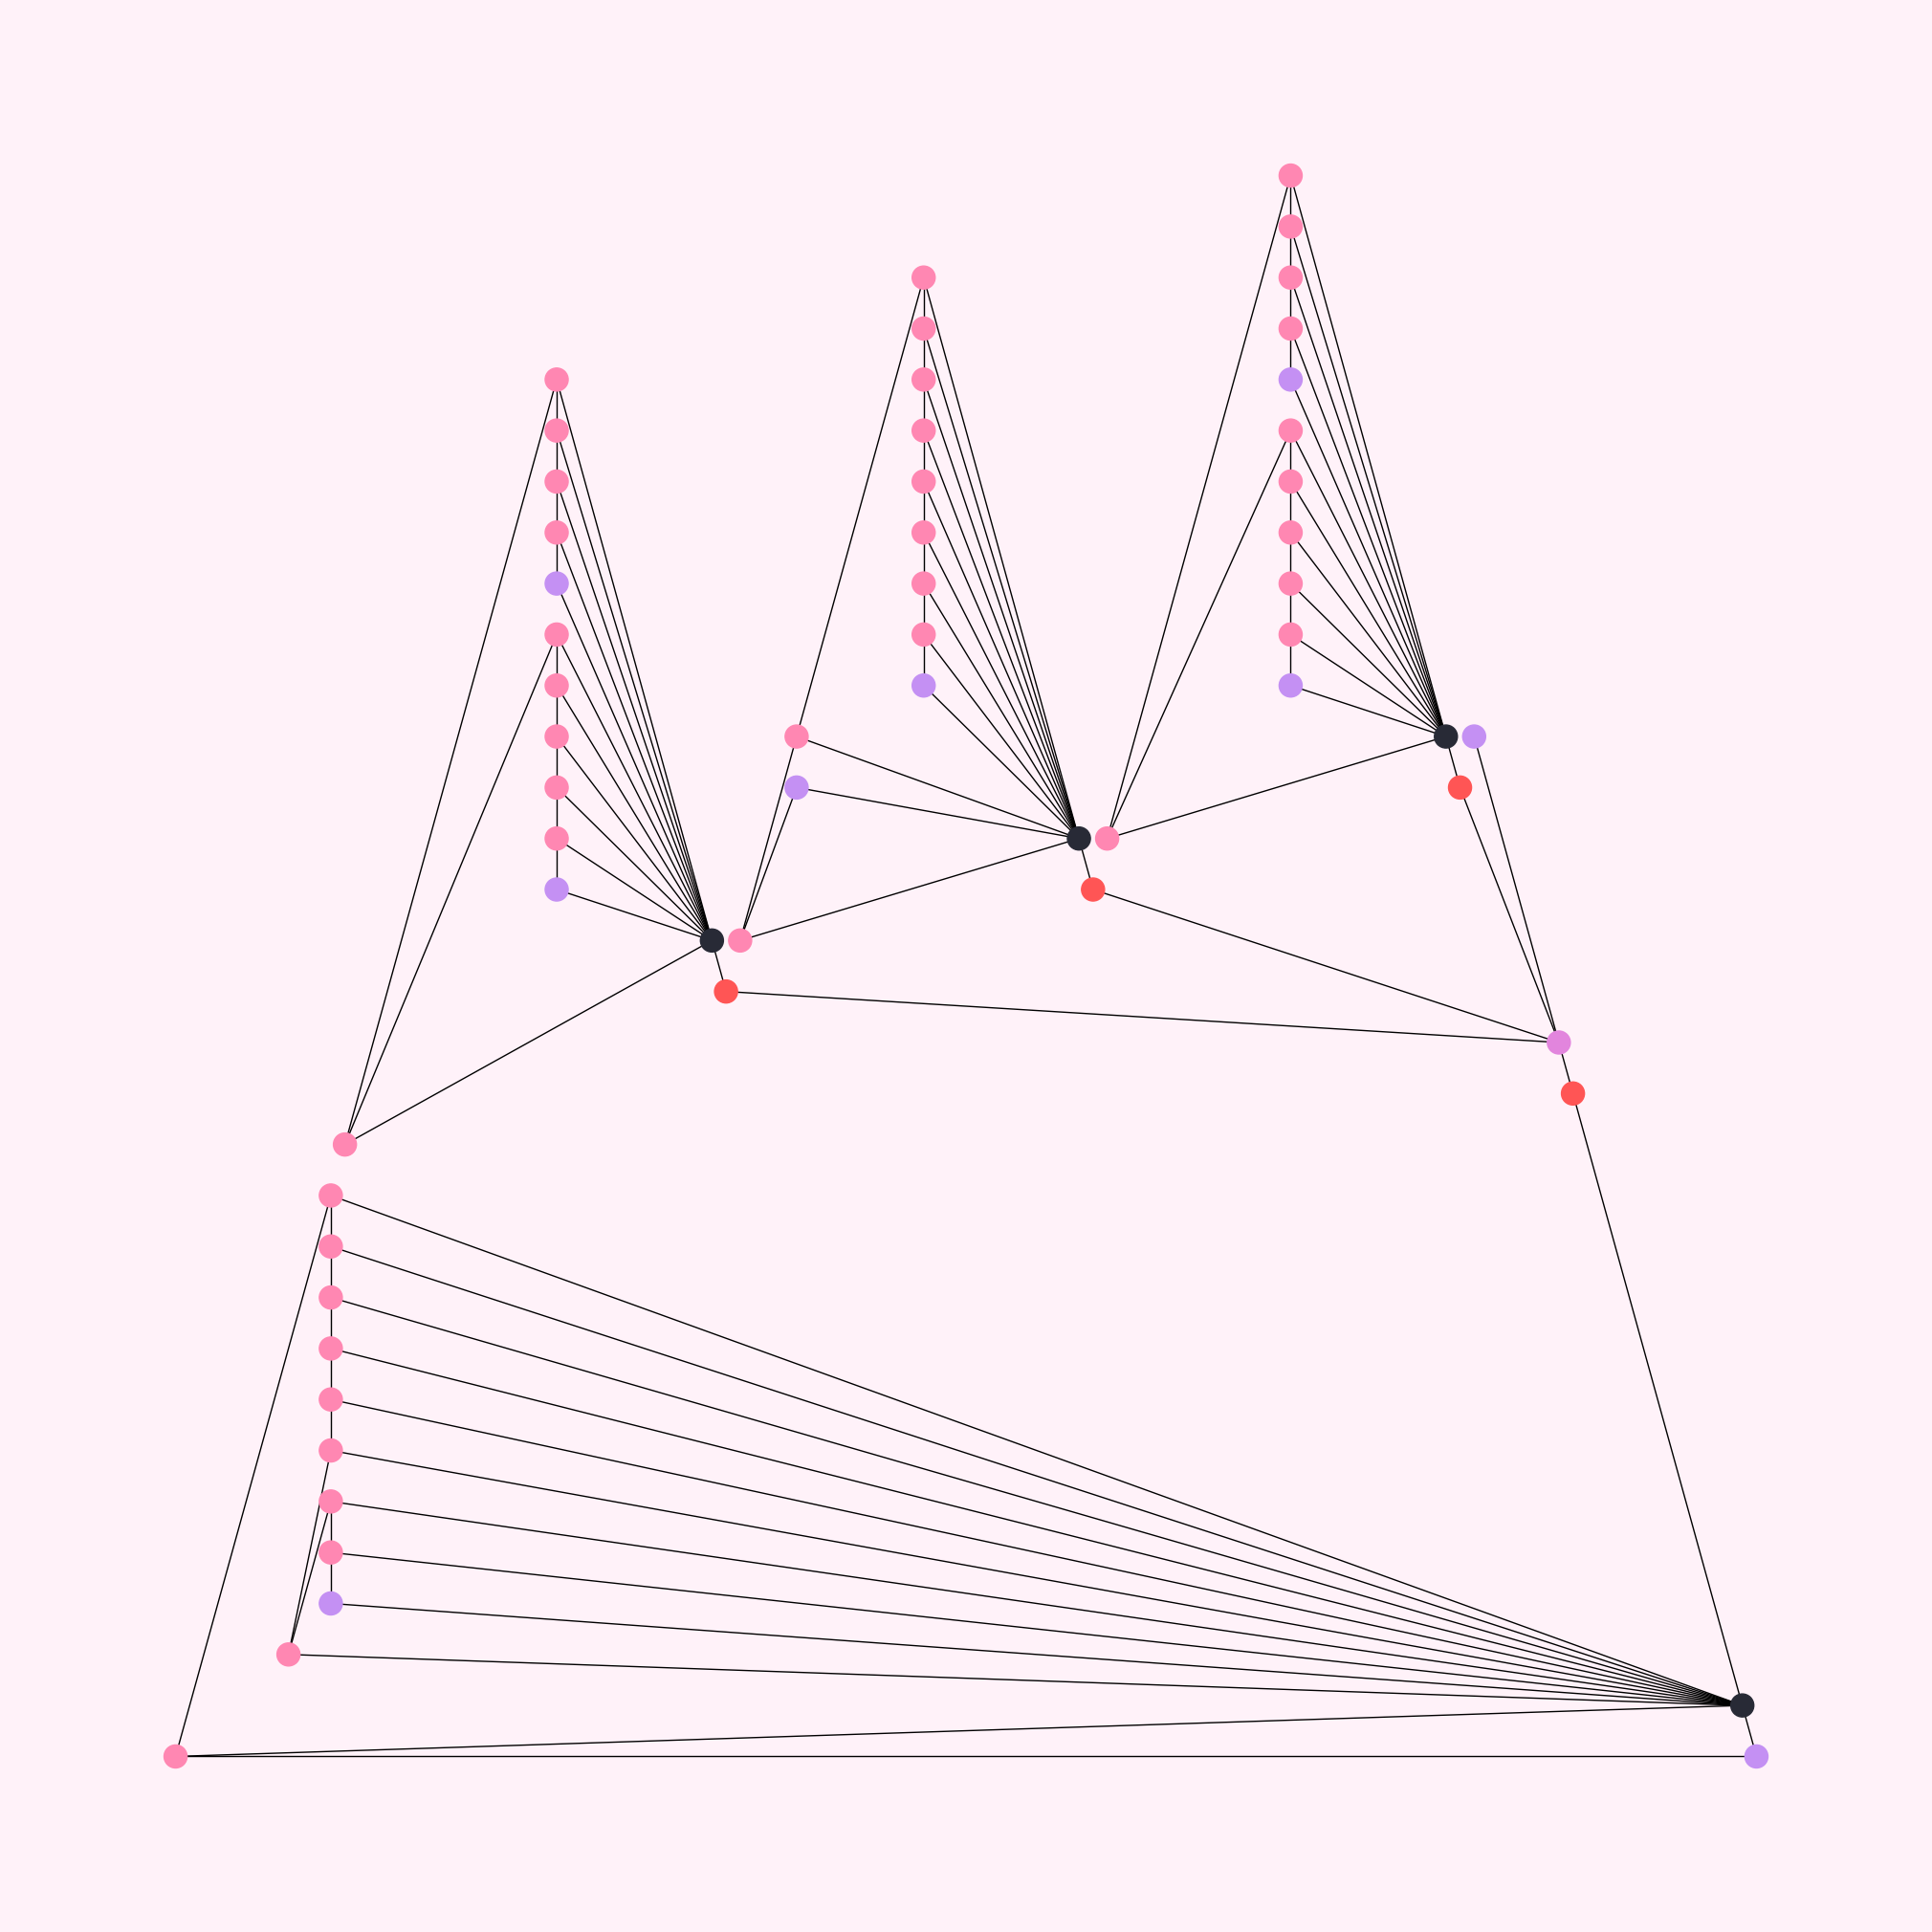

In [1779]:
plt.figure(figsize=(20, 20))
nx.draw_planar(G,with_labels=False, node_color = node_colors,cmap = cm)
plt.gcf().set_facecolor('#fff2f9')
plt.show()